In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [3]:
# Fijar semilla para que los datos sean reproducibles
np.random.seed(42)

# 1. Simulación de datos de 150 jugadores
n_jugadores = 150

nombres_ejemplo = [f'Jugador_{i}' for i in range(1, n_jugadores + 1)]
posiciones = np.random.choice(
    ['MC', 'MOC', 'ED', 'EI', 'DC'], size=n_jugadores
)
minutos = np.random.randint(300, 2800, size=n_jugadores)

# Métricas simuladas (distribuciones realistas)
xg_per90 = np.round(np.random.gamma(shape=2, scale=0.15, size=n_jugadores), 2)
xa_per90 = np.round(np.random.gamma(shape=1.5, scale=0.12, size=n_jugadores), 2)
key_passes_per90 = np.round(
    np.random.normal(loc=1.5, scale=0.6, size=n_jugadores).clip(0), 2
)
passes_into_penalty_area_per90 = np.round(
    np.random.normal(loc=1.2, scale=0.5, size=n_jugadores).clip(0), 2
)
progressive_passes_per90 = np.round(
    np.random.normal(loc=4.0, scale=1.5, size=n_jugadores).clip(0), 2
)
progressive_carries_per90 = np.round(
    np.random.normal(loc=2.5, scale=1.0, size=n_jugadores).clip(0), 2
)
dribbles_completed_per90 = np.round(
    np.random.normal(loc=1.0, scale=0.5, size=n_jugadores).clip(0), 2
)

# Creamos el DataFrame
df_raw = pd.DataFrame({
    'player_name': nombres_ejemplo,
    'position': posiciones,
    'minutes': minutos,
    'xg_per90': xg_per90,
    'xa_per90': xa_per90,
    'key_passes_per90': key_passes_per90,
    'passes_into_penalty_area_per90': passes_into_penalty_area_per90,
    'progressive_passes_per90': progressive_passes_per90,
    'progressive_carries_per90': progressive_carries_per90,
    'dribbles_completed_per90': dribbles_completed_per90,
})

# 2. Filtrado por minutos mínimos
MIN_MINUTOS = 900
df_filtered = df_raw[df_raw['minutes'] >= MIN_MINUTOS].copy()

# 3. Selección de métricas clave para el análisis
features_scouting = [
    'xg_per90',
    'xa_per90',
    'key_passes_per90',
    'passes_into_penalty_area_per90',
    'progressive_passes_per90',
    'progressive_carries_per90',
    'dribbles_completed_per90',
]

# 4. Aislar variables limpias
df_clean = df_filtered.dropna(subset=features_scouting).reset_index(drop=True)
X = df_clean[features_scouting]

print(f'Total de jugadores simulados: {len(df_raw)}')
print(f'Jugadores listos para análisis (>= 900 min): {len(df_clean)}')

Total de jugadores simulados: 150
Jugadores listos para análisis (>= 900 min): 121


In [4]:
from sklearn.preprocessing import StandardScaler

# 1. Inicializar el escalador
scaler = StandardScaler()

# 2. Ajustar y transformar las características numéricas
X_scaled = scaler.fit_transform(X)

# 3. Convertir de vuelta a DataFrame para mantener la estructura clara
df_scaled = pd.DataFrame(X_scaled, columns=features_scouting)

print("¡Métricas estandarizadas correctamente!")
print(f"Forma de la matriz procesada: {X_scaled.shape}")
df_scaled.head()

¡Métricas estandarizadas correctamente!
Forma de la matriz procesada: (121, 7)


,xg_per90,xa_per90,key_passes_per90,passes_into_penalty_area_per90,progressive_passes_per90,progressive_carries_per90,dribbles_completed_per90
0,0.504762,-0.896426,-0.553347,0.375550,0.040553,-0.632616,-1.389110
1,-0.344830,0.139194,0.299685,1.879428,1.411439,0.270292,0.423520
2,-0.533628,-0.460375,-0.408492,0.233291,0.858378,-0.532293,0.020714
3,-1.241622,-0.351363,-0.633821,0.477163,2.617583,1.547131,-1.545757
4,-0.392029,0.411725,0.879103,0.944585,-0.341883,-0.842382,0.826327


In [5]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Calcular la matriz de similaridad de coseno entre todos los jugadores
cosine_sim_matrix = cosine_similarity(X_scaled)


# 2. Función para buscar el Top N de jugadores más similares
def buscar_jugadores_similares(nombre_jugador, top_n=5):
  # Verificar si el jugador existe en el dataset filtrado
  if nombre_jugador not in df_clean['player_name'].values:
    return f"El jugador '{nombre_jugador}' no se encuentra en la base de datos."

  # Obtener el índice del jugador objetivo
  idx = df_clean[df_clean['player_name'] == nombre_jugador].index[0]

  # Obtener las puntuaciones de similaridad para este jugador
  sim_scores = list(enumerate(cosine_sim_matrix[idx]))

  # Ordenar los jugadores de mayor a menor similaridad
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

  # Excluir al propio jugador (índice 0) y tomar los Top N
  top_indices = [i[0] for i in sim_scores[1 : top_n + 1]]
  scores = [round(i[1], 4) for i in sim_scores[1 : top_n + 1]]

  # Crear DataFrame de resultados
  resultados = df_clean.iloc[top_indices][
      ['player_name', 'position', 'minutes']
  ].copy()
  resultados['similarity_score'] = scores

  return resultados


# 3. Probar la función con el primer jugador de la lista
jugador_prueba = df_clean['player_name'].iloc[0]
print(f'Buscando reemplazos/similares para: {jugador_prueba}\n')

resultados_df = buscar_jugadores_similares(jugador_prueba, top_n=5)
resultados_df

Buscando reemplazos/similares para: Jugador_1



,player_name,position,minutes,similarity_score
76,Jugador_90,ED,1982,0.8115
116,Jugador_145,EI,1515,0.7360
53,Jugador_63,DC,1834,0.7205
67,Jugador_80,EI,2693,0.6945
103,Jugador_128,EI,1345,0.6892


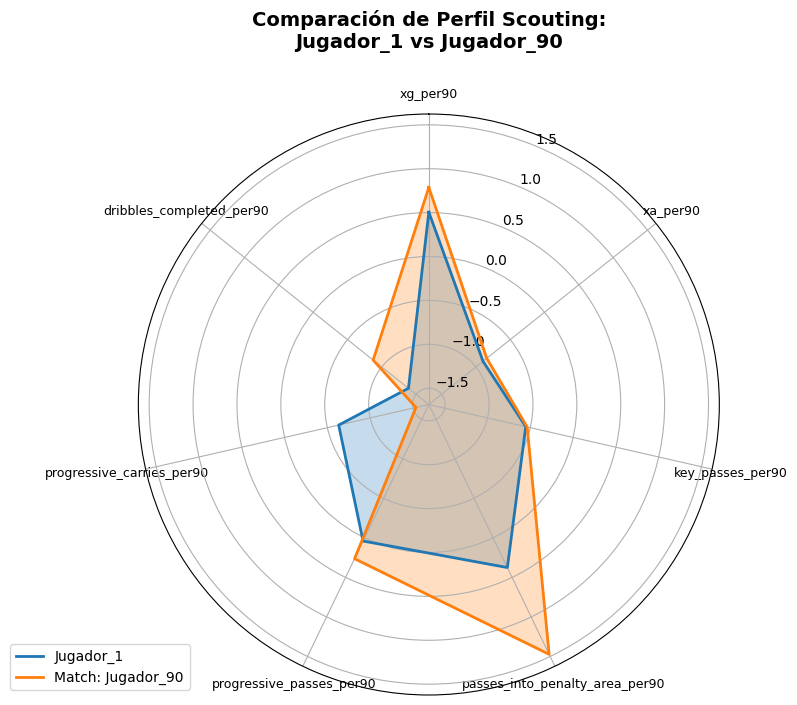

In [6]:
def graficar_radar_comparativo(jugador_target, jugador_match):
    # 1. Extraer índices de ambos jugadores
    idx_target = df_clean[df_clean['player_name'] == jugador_target].index[0]
    idx_match = df_clean[df_clean['player_name'] == jugador_match].index[0]

    # 2. Obtener sus métricas estandarizadas (X_scaled)
    val_target = X_scaled[idx_target].tolist()
    val_match = X_scaled[idx_match].tolist()

    # Cerrar el círculo del gráfico repitiendo el primer valor al final
    val_target += val_target[:1]
    val_match += val_match[:1]

    # Nombres de las variables para los ejes
    labels = features_scouting
    num_vars = len(labels)

    # Calcular los ángulos para cada eje en el radar
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
    angles += angles[:1]

    # 3. Configurar figura en proyección polar
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Ajustar posición del primer eje arriba (12 o'clock)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Dibujar las etiquetas de las métricas
    plt.xticks(angles[:-1], labels, size=9)

    # Dibujar Jugador Target
    ax.plot(angles, val_target, linewidth=2, linestyle='solid', label=jugador_target, color='#1f77b4')
    ax.fill(angles, val_target, color='#1f77b4', alpha=0.25)

    # Dibujar Jugador Match (#1 similar)
    ax.plot(angles, val_match, linewidth=2, linestyle='solid', label=f'Match: {jugador_match}', color='#ff7f0e')
    ax.fill(angles, val_match, color='#ff7f0e', alpha=0.25)

    # Estilos finales
    plt.title(f'Comparación de Perfil Scouting:\n{jugador_target} vs {jugador_match}', size=14, y=1.1, weight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.tight_layout()
    plt.show()

# Probamos con el jugador de origen y su primer reemplazo del Top 5
jugador_origen = df_clean['player_name'].iloc[0]
primer_match = resultados_df['player_name'].iloc[0]

graficar_radar_comparativo(jugador_origen, primer_match)

In [7]:
# Guardar los resultados procesados con los scores de similaridad para Power BI
df_clean.to_csv('jugadores_scouting_procesado.csv', index=False)